In [1]:
import os
import sys
import gc
from pathlib import Path
import pandas as pd

import numpy as np
import torch
import matplotlib.pyplot as plt

from matplotlib.colors import to_rgb, LinearSegmentedColormap
from matplotlib.lines import Line2D
from mpl_toolkits.mplot3d.art3d import Line3DCollection

PROJECT_ROOT = Path("/home/ganchao/isilon/AllStaff/DCF")
os.chdir(PROJECT_ROOT)
sys.path.insert(0, str(PROJECT_ROOT))

from plot_sim_results_v7 import read_model, proj_to_latent, latent_mu

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.set_default_device(device)

U_ID = "U333"
DATA_VARIANT = "smooth_z"
TAU_LATENT = 0.0
DIM_TO_KEEP = 3
DIMS = (0, 1, 2)

CALL_TYPES = ["phee", "twitter", "trill", "trill_phee"]

CKPTS = {
    "phee": "network-snapshot-049674.pkl",
    "twitter": "network-snapshot-049674.pkl",
    "trill": "network-snapshot-049674.pkl",
    "trill_phee": "network-snapshot-049674.pkl",
}

BASE_COLORS = {
    "phee": "#d62728",
    "twitter": "#1f77b4",
    "trill": "#2ca02c",
    "trill_phee": "#9467bd",
}

COLOR_DARKEN = 0.45      # 0 = black, 1 = original color
ROBUST_Q = (2, 98)       # axis limits ignore extreme tails
PLOT_CENTERED = True     # subtract starting point for visualization

SAVE_FIGS = True
PLOT_DIR = PROJECT_ROOT / f"paper_fig/auditory_{U_ID}_all_calls_flowed_3d"
PLOT_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
def load_samples(path):
    x = np.load(path, allow_pickle=True)["samples"]

    if isinstance(x, np.ndarray) and x.ndim == 3:
        return [x[i].astype(np.float32) for i in range(x.shape[0])]

    return [np.asarray(a, dtype=np.float32) for a in x.tolist()]


def run_dir_for(call_type):
    data_name = f"auditory_{U_ID}_{call_type}_{DATA_VARIANT}_lag0_none"
    root = PROJECT_ROOT / f"out/auditory/{U_ID}_{call_type}_all_{DATA_VARIANT}/dimk_lag0/t/none"
    return sorted(root.glob(f"*-{data_name}-prp-uncond-*"))[-1]


def data_dir_for(call_type):
    return PROJECT_ROOT / f"out/auditory/{U_ID}_{call_type}_all_{DATA_VARIANT}/dimk_lag0/t/none/data"


def to_numpy_list(xs):
    out = []

    for x in xs:
        if torch.is_tensor(x):
            out.append(x.detach().cpu().numpy())
        else:
            out.append(np.asarray(x))

    return out


def mean_traj(xs):
    T = min(x.shape[0] for x in xs)
    return np.stack([x[:T] for x in xs], axis=0).mean(axis=0)

def darken_color(color, amount=0.45):
    rgb = np.array(to_rgb(color))
    return tuple(amount * rgb)

def cmap_to_dark(color):
    return LinearSegmentedColormap.from_list(
        "",
        [to_rgb(color), darken_color(color, COLOR_DARKEN)],
    )

def prep_xyz(xyz):
    xyz = np.asarray(xyz, dtype=float)

    if PLOT_CENTERED:
        xyz = xyz - xyz[0:1]

    return xyz

def add_time_line(ax, xyz, color, lw=3, alpha=1):
    xyz = prep_xyz(xyz)

    segs = np.stack([xyz[:-1], xyz[1:]], axis=1)
    t = np.linspace(0, 1, xyz.shape[0])

    lc = Line3DCollection(
        segs,
        colors=cmap_to_dark(color)(t[1:]),
        linewidth=lw,
        alpha=alpha,
    )
    ax.add_collection3d(lc)

    ax.scatter(xyz[0, 0], xyz[0, 1], xyz[0, 2], color=color, edgecolor="k", s=45)
    ax.scatter(xyz[-1, 0], xyz[-1, 1], xyz[-1, 2], color=darken_color(color), edgecolor="k", s=45, marker="s")


def set_limits_from_trajs(ax, trajs, robust=False, q=(2, 98), pad_frac=0.15):
    trajs_plot = [prep_xyz(x) for x in trajs]
    xyz = np.concatenate(trajs_plot, axis=0)

    if robust:
        lo = np.percentile(xyz, q[0], axis=0)
        hi = np.percentile(xyz, q[1], axis=0)
    else:
        lo = xyz.min(axis=0)
        hi = xyz.max(axis=0)

    mid = 0.5 * (lo + hi)
    width = hi - lo
    rad = 0.5 * np.max(width) * (1 + pad_frac)
    rad = max(rad, 1e-8)

    ax.set_xlim(mid[0] - rad, mid[0] + rad)
    ax.set_ylim(mid[1] - rad, mid[1] + rad)
    ax.set_zlim(mid[2] - rad, mid[2] + rad)

    try:
        ax.set_box_aspect((1, 1, 1))
    except Exception:
        pass


def savefig(name):
    if SAVE_FIGS:
        path = PLOT_DIR / name
        plt.savefig(path, dpi=200, bbox_inches="tight")
        print("saved:", path)

In [3]:
results = {}

for call_type in CALL_TYPES:
    print("loading", call_type)

    run_dir = run_dir_for(call_type)
    ckpt = CKPTS[call_type]
    samples = load_samples(data_dir_for(call_type) / "dataset_samples.npz")

    flow_net, dyn_net, encoder, lag = read_model(str(run_dir) + "/", "/" + ckpt)

    flow_net = flow_net.to(device).eval()
    encoder = encoder.to(device).eval()

    flowed = proj_to_latent(samples, flow_net, TAU_LATENT, device)

    mu_tensors, _, _, _, _ = latent_mu(
        flowed,
        encoder,
        DIM_TO_KEEP,
        device,
        fullRes=True,
        resid_tol=1e-15,
    )

    mu = to_numpy_list(mu_tensors)
    mu = [x[:, list(DIMS)] for x in mu]

    results[call_type] = {
        "mu": mu,
        "mean": mean_traj(mu),
        "run_dir": run_dir,
        "ckpt": ckpt,
    }

    print(" ", ckpt)
    print(" ", len(mu), mu[0].shape)

    del flow_net, dyn_net, encoder, flowed, mu_tensors
    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

loading phee


100%|███████████████████████████████████████████| 50/50 [00:01<00:00, 30.18it/s]


  network-snapshot-049674.pkl
  50 (2490, 3)
loading twitter


100%|███████████████████████████████████████████| 50/50 [00:01<00:00, 40.44it/s]


  network-snapshot-049674.pkl
  50 (2007, 3)
loading trill


100%|███████████████████████████████████████████| 50/50 [00:01<00:00, 38.42it/s]


  network-snapshot-049674.pkl
  50 (1416, 3)
loading trill_phee


100%|███████████████████████████████████████████| 50/50 [00:01<00:00, 36.74it/s]


  network-snapshot-049674.pkl
  50 (2381, 3)


In [4]:
# Align +/- signs across call types using trajectory direction, not raw value correlation.

REF_CALL = "phee"

def resample_traj_to_T(x, T):
    x = np.asarray(x)
    old_t = np.linspace(0, 1, x.shape[0])
    new_t = np.linspace(0, 1, T)

    out = np.zeros((T, x.shape[1]), dtype=x.dtype)
    for j in range(x.shape[1]):
        out[:, j] = np.interp(new_t, old_t, x[:, j])

    return out

def sign_by_velocity_reference(ref_mean, target_mean):
    T = min(ref_mean.shape[0], target_mean.shape[0])

    ref = resample_traj_to_T(ref_mean, T)
    tgt = resample_traj_to_T(target_mean, T)

    d_ref = np.diff(ref, axis=0)
    d_tgt = np.diff(tgt, axis=0)

    velocity_score = np.sum(d_ref * d_tgt, axis=0)

    ref_disp = ref[-1] - ref[0]
    tgt_disp = tgt[-1] - tgt[0]
    displacement_score = ref_disp * tgt_disp

    # velocity alignment.
    signs = np.where(velocity_score >= 0, 1.0, -1.0)

    return signs, velocity_score, displacement_score

# Save original unaligned trajectories once.
for call_type in CALL_TYPES:
    if "mu_unaligned" not in results[call_type]:
        results[call_type]["mu_unaligned"] = [
            x.copy() for x in results[call_type]["mu"]
        ]
        results[call_type]["mean_unaligned"] = results[call_type]["mean"].copy()

ref_mean = results[REF_CALL]["mean_unaligned"]

sign_rows = []

for call_type in CALL_TYPES:
    signs, vel_score, disp_score = sign_by_velocity_reference(
        ref_mean,
        results[call_type]["mean_unaligned"],
    )

    results[call_type]["mu"] = [
        x * signs[None, :]
        for x in results[call_type]["mu_unaligned"]
    ]

    results[call_type]["mean"] = mean_traj(results[call_type]["mu"])
    results[call_type]["signs"] = signs

    sign_rows.append({
        "call_type": call_type,
        "sign_μ1": signs[0],
        "sign_μ2": signs[1],
        "sign_μ3": signs[2],
        "velocity_score_μ1": vel_score[0],
        "velocity_score_μ2": vel_score[1],
        "velocity_score_μ3": vel_score[2],
        "displacement_score_μ1": disp_score[0],
        "displacement_score_μ2": disp_score[1],
        "displacement_score_μ3": disp_score[2],
    })

pd.DataFrame(sign_rows)

,call_type,sign_μ1,sign_μ2,sign_μ3,velocity_score_μ1,velocity_score_μ2,velocity_score_μ3,displacement_score_μ1,displacement_score_μ2,displacement_score_μ3
0,phee,1.0,1.0,1.0,0.534028,0.531492,0.527354,0.005026,0.052654,0.008916
1,twitter,-1.0,-1.0,-1.0,-0.026510,-0.024419,-0.005622,-0.031604,-0.067880,0.011836
2,trill,-1.0,1.0,-1.0,-0.032638,0.042714,-0.063400,-0.017214,0.085262,0.033063
3,trill_phee,1.0,-1.0,1.0,0.020061,-0.021842,0.065930,0.007233,0.108294,-0.014259


saved: /home/ganchao/isilon/AllStaff/DCF/paper_fig/auditory_U333_all_calls_flowed_3d/U333_all_calls_flowed_3d_mean_overlay.png


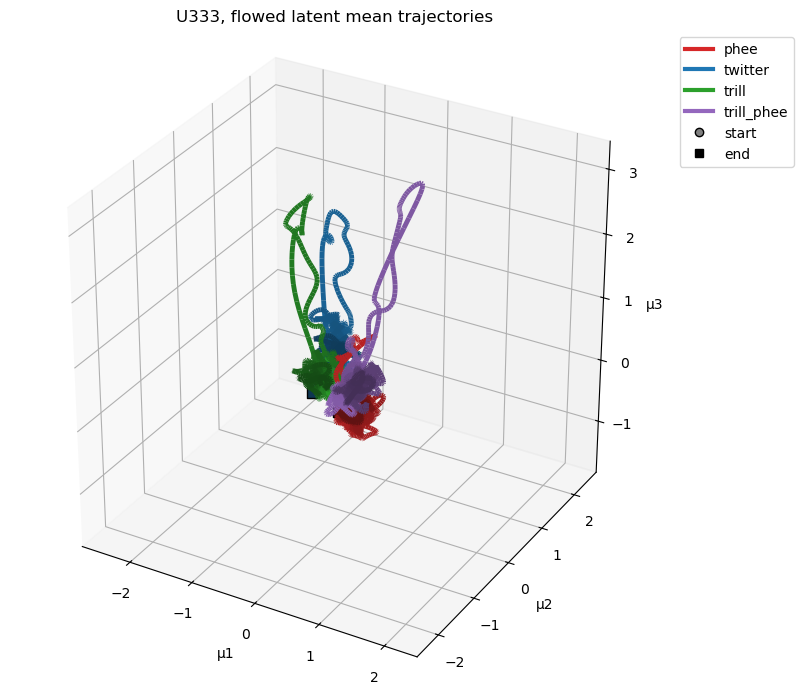

In [5]:
fig = plt.figure(figsize=(8, 7))
ax = fig.add_subplot(111, projection="3d")

mean_trajs = []

for call_type in CALL_TYPES:
    xyz = results[call_type]["mean"]
    mean_trajs.append(xyz)

    add_time_line(
        ax,
        xyz,
        color=BASE_COLORS[call_type],
        lw=3.5,
        alpha=1.0,
    )

# Use all four mean trajectories for limits, with enough padding.
# This guarantees all mean trajectories are inside the axes.
set_limits_from_trajs(
    ax,
    mean_trajs,
    robust=True,
    pad_frac=1.2,
)

ax.set_xlabel(f"μ{DIMS[0] + 1}")
ax.set_ylabel(f"μ{DIMS[1] + 1}")
ax.set_zlabel(f"μ{DIMS[2] + 1}")
ax.set_title(f"{U_ID}, flowed latent mean trajectories")

handles = [
    Line2D([0], [0], color=BASE_COLORS[c], lw=3, label=c)
    for c in CALL_TYPES
]
handles += [
    Line2D([0], [0], marker="o", color="w", markerfacecolor="gray", markeredgecolor="k", label="start"),
    Line2D([0], [0], marker="s", color="w", markerfacecolor="black", markeredgecolor="k", label="end"),
]

ax.legend(handles=handles, bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()

savefig(f"{U_ID}_all_calls_flowed_3d_mean_overlay.png")
plt.show()

saved: /home/ganchao/isilon/AllStaff/DCF/paper_fig/auditory_U333_all_calls_flowed_3d/U333_all_calls_flowed_3d_mean_panels.png


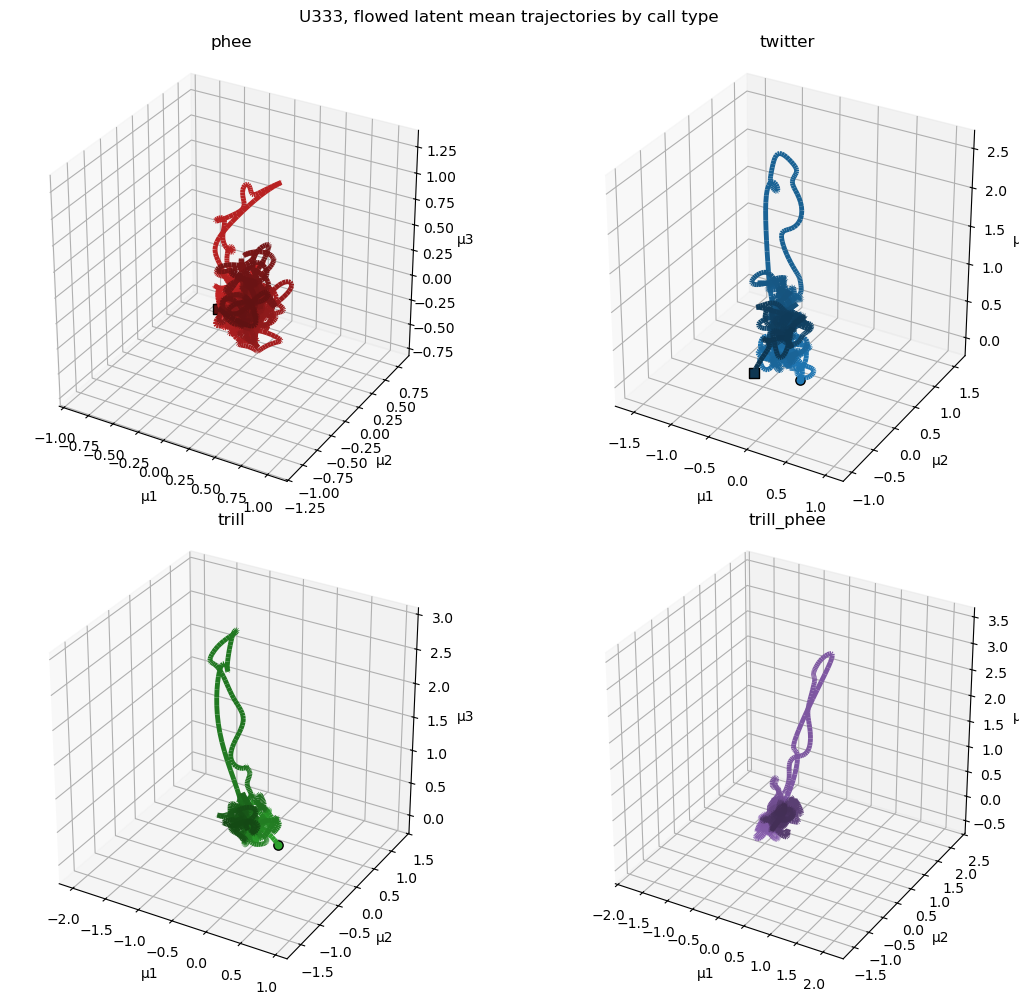

In [6]:
fig = plt.figure(figsize=(12, 10))

for i, call_type in enumerate(CALL_TYPES, start=1):
    ax = fig.add_subplot(2, 2, i, projection="3d")

    xyz = results[call_type]["mean"]

    add_time_line(
        ax,
        xyz,
        color=BASE_COLORS[call_type],
        lw=3.5,
        alpha=1.0,
    )

    # Important: use this call type's own mean trajectory for limits
    set_limits_from_trajs(ax, [xyz], robust=False, pad_frac=0.20)

    ax.set_title(call_type)
    ax.set_xlabel(f"μ{DIMS[0] + 1}")
    ax.set_ylabel(f"μ{DIMS[1] + 1}")
    ax.set_zlabel(f"μ{DIMS[2] + 1}")

fig.suptitle(f"{U_ID}, flowed latent mean trajectories by call type")
plt.tight_layout()

savefig(f"{U_ID}_all_calls_flowed_3d_mean_panels.png")
plt.show()

In [7]:
# for call_type in CALL_TYPES:
#     fig = plt.figure(figsize=(7, 6))
#     ax = fig.add_subplot(111, projection="3d")

#     color = BASE_COLORS[call_type]

#     for xyz in results[call_type]["mu"]:
#         xyz_plot = prep_xyz(xyz)
        
#         ax.plot(
#             xyz_plot[:, 0],
#             xyz_plot[:, 1],
#             xyz_plot[:, 2],
#             color=color,
#             alpha=0.12,
#             lw=0.8,
#         )

#     add_time_line(
#         ax,
#         results[call_type]["mean"],
#         color=color,
#         lw=4.0,
#         alpha=1.0,
#     )


#     set_limits_from_trajs(ax, mean_trajs, robust=False, pad_frac=0.25)
#     # all_xyz = np.concatenate(results[call_type]["mu"], axis=0)
#     # set_limits(ax, all_xyz)

#     ax.set_title(f"{call_type}, flowed latent trajectories")
#     ax.set_xlabel(f"μ{DIMS[0] + 1}")
#     ax.set_ylabel(f"μ{DIMS[1] + 1}")
#     ax.set_zlabel(f"μ{DIMS[2] + 1}")

#     plt.tight_layout()
#     savefig(f"{U_ID}_{call_type}_flowed_3d_trials_and_mean.png")
#     plt.show()